In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import numpy as np

C:\Users\mirna\anaconda3\envs\network_env\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv('condition_subgroups/condition_subgroups_bootstrap_results.csv')
df

,Cohort,Subgroup,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort,Diabetes (d),40643,2077,Random Forest,ROC_AUC,0.727028,0.716785,0.738702,0.7270 (0.7168 - 0.7387)
1,Nationwide Cohort,Diabetes (d),40643,2077,Random Forest,PR_AUC,0.437891,0.415862,0.460870,0.4379 (0.4159 - 0.4609)
2,Nationwide Cohort,Diabetes (d),40643,2077,Random Forest,F1_Score,0.481762,0.467063,0.498487,0.4818 (0.4671 - 0.4985)
3,Nationwide Cohort,Diabetes (d),40643,2077,Random Forest,Accuracy,0.645132,0.635376,0.654696,0.6451 (0.6354 - 0.6547)
4,Nationwide Cohort,Diabetes (d),40643,2077,Random Forest,Precision,0.367377,0.352915,0.385163,0.3674 (0.3529 - 0.3852)
...,...,...,...,...,...,...,...,...,...,...
1107,Texas Cohort,Diabetes + Heart Failure + Hypertension (d+hf+...,925,758,HIR-M3 Transformer,Accuracy,0.528622,0.453919,0.600000,0.5286 (0.4539 - 0.6000)
1108,Texas Cohort,Diabetes + Heart Failure + Hypertension (d+hf+...,925,758,HIR-M3 Transformer,Precision,0.620470,0.441085,0.766667,0.6205 (0.4411 - 0.7667)
1109,Texas Cohort,Diabetes + Heart Failure + Hypertension (d+hf+...,925,758,HIR-M3 Transformer,Recall_Sensitivity,0.203508,0.131217,0.275612,0.2035 (0.1312 - 0.2756)
1110,Texas Cohort,Diabetes + Heart Failure + Hypertension (d+hf+...,925,758,HIR-M3 Transformer,Specificity,0.869622,0.797866,0.929293,0.8696 (0.7979 - 0.9293)


In [3]:
subgroup_labels = {
    "Diabetes (d)": "D",
    "Heart Failure (hf)": "HF",
    "Hypertension (hyp)": "Hyp",
    "Diabetes + Heart Failure (d+hf)": "D + HF",
    "Diabetes + Hypertension (d+hyp)": "D + Hyp",
    "Heart Failure + Hypertension (hf+hyp)": "HF + Hyp",
    "Diabetes + Heart Failure + Hypertension (d+hf+hyp)": (
        "D + HF + Hyp"
    ),
}

df["Subgroup"] = df["Subgroup"].replace(subgroup_labels)
df

,Cohort,Subgroup,Cohort Size,Num Features,Model,Metric,Mean,CI_Lower,CI_Upper,Formatted
0,Nationwide Cohort,D,40643,2077,Random Forest,ROC_AUC,0.727028,0.716785,0.738702,0.7270 (0.7168 - 0.7387)
1,Nationwide Cohort,D,40643,2077,Random Forest,PR_AUC,0.437891,0.415862,0.460870,0.4379 (0.4159 - 0.4609)
2,Nationwide Cohort,D,40643,2077,Random Forest,F1_Score,0.481762,0.467063,0.498487,0.4818 (0.4671 - 0.4985)
3,Nationwide Cohort,D,40643,2077,Random Forest,Accuracy,0.645132,0.635376,0.654696,0.6451 (0.6354 - 0.6547)
4,Nationwide Cohort,D,40643,2077,Random Forest,Precision,0.367377,0.352915,0.385163,0.3674 (0.3529 - 0.3852)
...,...,...,...,...,...,...,...,...,...,...
1107,Texas Cohort,D + HF + Hyp,925,758,HIR-M3 Transformer,Accuracy,0.528622,0.453919,0.600000,0.5286 (0.4539 - 0.6000)
1108,Texas Cohort,D + HF + Hyp,925,758,HIR-M3 Transformer,Precision,0.620470,0.441085,0.766667,0.6205 (0.4411 - 0.7667)
1109,Texas Cohort,D + HF + Hyp,925,758,HIR-M3 Transformer,Recall_Sensitivity,0.203508,0.131217,0.275612,0.2035 (0.1312 - 0.2756)
1110,Texas Cohort,D + HF + Hyp,925,758,HIR-M3 Transformer,Specificity,0.869622,0.797866,0.929293,0.8696 (0.7979 - 0.9293)


In [4]:
print(df['Model'].unique())
df['Subgroup'].unique()

<ArrowStringArray>
[       'Random Forest',    'Gradient Boosting',  'Logistic Regression',
             'CatBoost',             'LightGBM',              'XGBoost',
         'Standard MLP', 'Standard Transformer',   'HIR-M3 Transformer',
    'SAINT Transformer']
Length: 10, dtype: str


<ArrowStringArray>
['D', 'HF', 'Hyp', 'D + HF', 'D + Hyp', 'HF + Hyp', 'D + HF + Hyp']
Length: 7, dtype: str

In [5]:
id_cols = [
    "Cohort",
    "Subgroup",
    "Cohort Size",
    "Num Features",
    "Model",
]

# Ensure no accidental duplicate result rows per model/metric.
# If duplicates are expected, choose an appropriate aggregation function.
results_wide_df = (
    df
    .pivot_table(
        index=id_cols,
        columns="Metric",
        values=['Formatted'],
        aggfunc="first"
    )
)

results_wide_df.columns = [
    f"{metric.replace('-', '_').replace(' ', '_')}_{stat}"
    for stat, metric in results_wide_df.columns
]

results_wide_df = results_wide_df.reset_index()
results_wide_df

,Cohort,Subgroup,Cohort Size,Num Features,Model,Accuracy_Formatted,Brier_Score_Formatted,F1_Score_Formatted,PR_AUC_Formatted,Precision_Formatted,ROC_AUC_Formatted,Recall_Sensitivity_Formatted,Specificity_Formatted
0,Nationwide Cohort,D,40643,2077,CatBoost,0.7220 (0.7121 - 0.7321),0.1824 (0.1785 - 0.1860),0.5365 (0.5209 - 0.5548),0.5336 (0.5115 - 0.5561),0.4420 (0.4241 - 0.4627),0.7881 (0.7783 - 0.7979),0.6825 (0.6627 - 0.7041),0.7342 (0.7242 - 0.7461)
1,Nationwide Cohort,D,40643,2077,Gradient Boosting,0.7131 (0.7040 - 0.7245),0.1903 (0.1875 - 0.1934),0.5295 (0.5121 - 0.5482),0.5152 (0.4902 - 0.5365),0.4316 (0.4132 - 0.4503),0.7781 (0.7679 - 0.7881),0.6850 (0.6639 - 0.7078),0.7217 (0.7113 - 0.7329)
2,Nationwide Cohort,D,40643,2077,HIR-M3 Transformer,0.4893 (0.4793 - 0.4983),0.2519 (0.2506 - 0.2531),0.3906 (0.3768 - 0.4054),0.2961 (0.2803 - 0.3131),0.2717 (0.2598 - 0.2839),0.5892 (0.5751 - 0.6036),0.6943 (0.6747 - 0.7125),0.4260 (0.4149 - 0.4369)
3,Nationwide Cohort,D,40643,2077,LightGBM,0.6934 (0.6847 - 0.7037),0.1659 (0.1622 - 0.1697),0.5235 (0.5073 - 0.5414),0.5131 (0.4917 - 0.5335),0.4131 (0.3965 - 0.4310),0.7759 (0.7667 - 0.7863),0.7145 (0.6963 - 0.7365),0.6868 (0.6760 - 0.7004)
4,Nationwide Cohort,D,40643,2077,Logistic Regression,0.6919 (0.6832 - 0.7023),0.2042 (0.1994 - 0.2091),0.4883 (0.4706 - 0.5051),0.4650 (0.4408 - 0.4875),0.4013 (0.3839 - 0.4188),0.7271 (0.7144 - 0.7415),0.6237 (0.5993 - 0.6447),0.7129 (0.7030 - 0.7231)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Texas Cohort,Hyp,16161,758,Random Forest,0.6639 (0.6502 - 0.6783),0.1627 (0.1568 - 0.1676),0.5002 (0.4765 - 0.5244),0.4635 (0.4245 - 0.4953),0.3936 (0.3702 - 0.4176),0.7429 (0.7270 - 0.7592),0.6866 (0.6523 - 0.7210),0.6566 (0.6409 - 0.6747)
135,Texas Cohort,Hyp,16161,758,SAINT Transformer,0.3177 (0.3031 - 0.3335),0.1527 (0.1458 - 0.1586),0.4176 (0.3994 - 0.4358),0.5066 (0.4729 - 0.5410),0.2641 (0.2496 - 0.2788),0.7808 (0.7658 - 0.7973),0.9985 (0.9961 - 1.0000),0.0967 (0.0847 - 0.1090)
136,Texas Cohort,Hyp,16161,758,Standard MLP,0.7133 (0.6966 - 0.7287),0.2042 (0.1960 - 0.2121),0.5015 (0.4762 - 0.5266),0.4862 (0.4546 - 0.5157),0.4370 (0.4129 - 0.4654),0.7480 (0.7327 - 0.7647),0.5889 (0.5565 - 0.6205),0.7536 (0.7357 - 0.7711)
137,Texas Cohort,Hyp,16161,758,Standard Transformer,0.6516 (0.6359 - 0.6675),0.1995 (0.1927 - 0.2062),0.5235 (0.5004 - 0.5457),0.4850 (0.4515 - 0.5163),0.3937 (0.3726 - 0.4158),0.7623 (0.7461 - 0.7781),0.7812 (0.7503 - 0.8085),0.6095 (0.5887 - 0.6298)


In [6]:
results_wide_df.to_csv('condition_subgroups/modeling_results_combined.csv', index=False)
results_wide_df.columns

Index(['Cohort', 'Subgroup', 'Cohort Size', 'Num Features', 'Model',
       'Accuracy_Formatted', 'Brier_Score_Formatted', 'F1_Score_Formatted',
       'PR_AUC_Formatted', 'Precision_Formatted', 'ROC_AUC_Formatted',
       'Recall_Sensitivity_Formatted', 'Specificity_Formatted'],
      dtype='str')

In [7]:
sns.set_theme(style="whitegrid", context="notebook")

metrics = [
    "Accuracy_Formatted",
    "Brier_Score_Formatted",
    "F1_Score_Formatted",
    "PR_AUC_Formatted",
    "Precision_Formatted",
    "ROC_AUC_Formatted",
    "Recall_Sensitivity_Formatted",
    "Specificity_Formatted",
]

metric_labels = {
    "Accuracy_Formatted": "Accuracy",
    "Brier_Score_Formatted": "Brier Score",
    "F1_Score_Formatted": "F1",
    "PR_AUC_Formatted": "PR AUC",
    "Precision_Formatted": "Precision",
    "ROC_AUC_Formatted": "ROC AUC",
    "Recall_Sensitivity_Formatted": "Recall",
    "Specificity_Formatted": "Specificity",
}

# Prevent duplicate parsed columns if you rerun the notebook cell
value_columns = [f"{metric}_value" for metric in metrics]
results_wide_df = results_wide_df.drop(
    columns=[col for col in value_columns if col in results_wide_df.columns],
    errors="ignore",
)

for metric in metrics:
    results_wide_df[f"{metric}_value"] = pd.to_numeric(
        results_wide_df[metric]
        .astype(str)
        .str.extract(r"^\s*([0-9]*\.?[0-9]+)")[0],
        errors="coerce",
    )

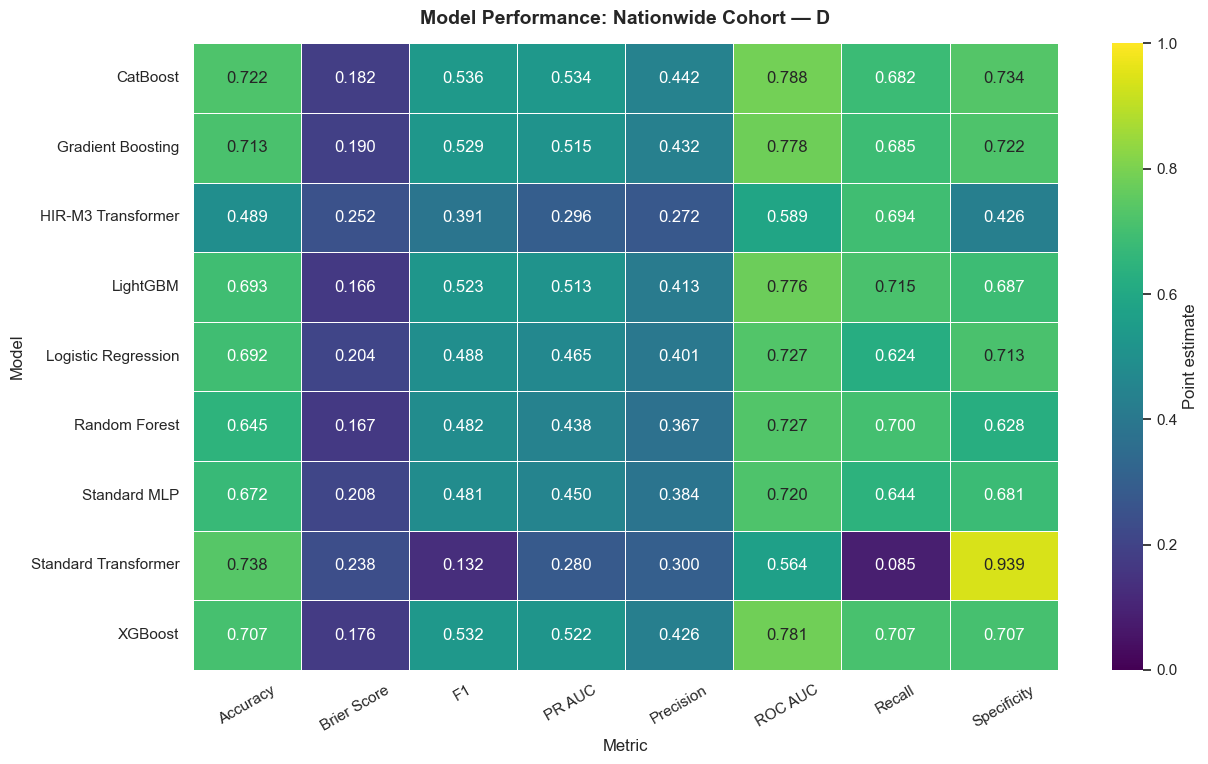

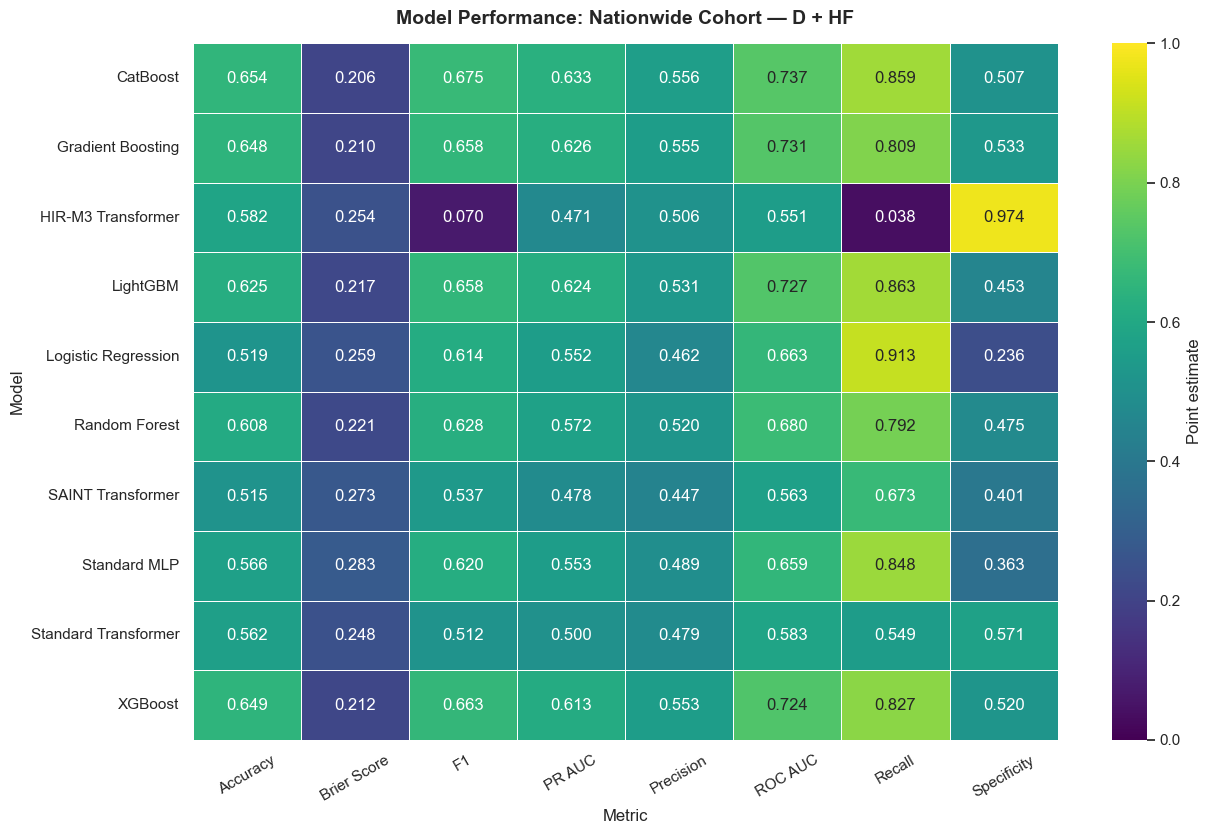

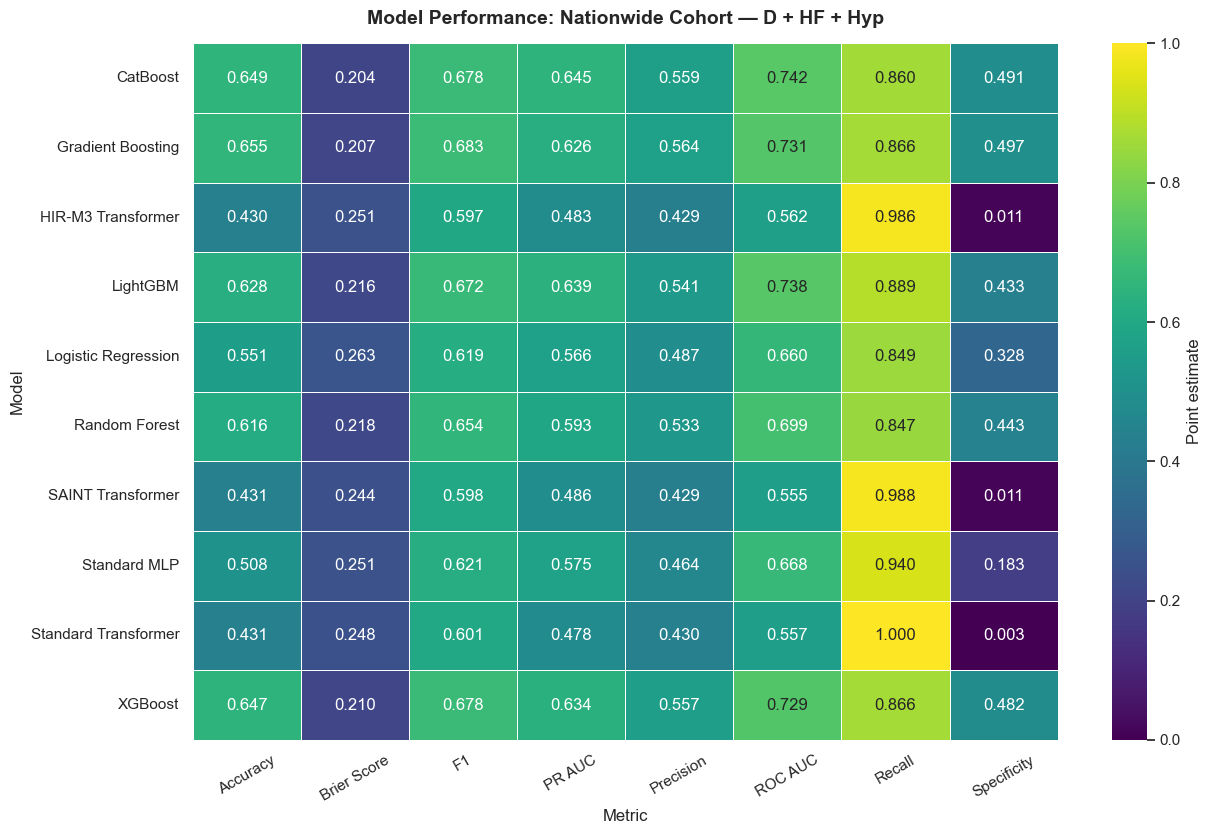

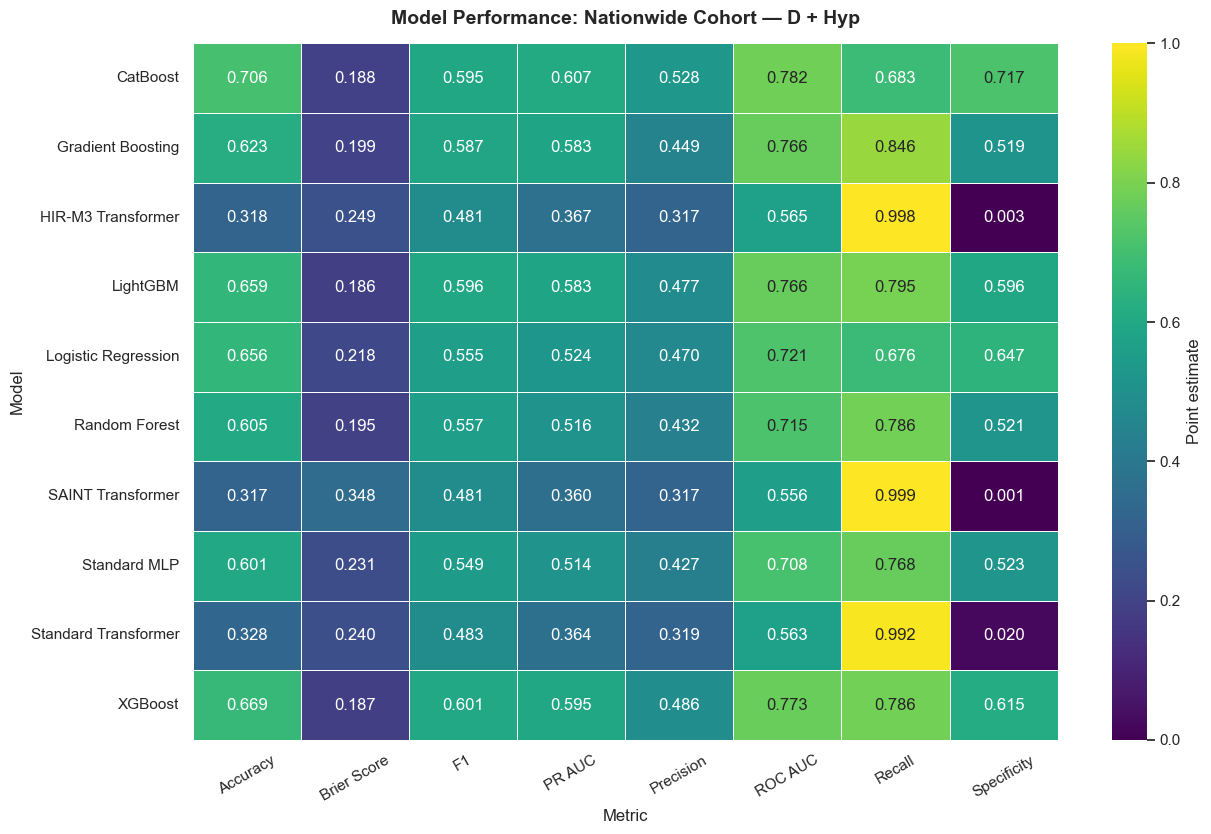

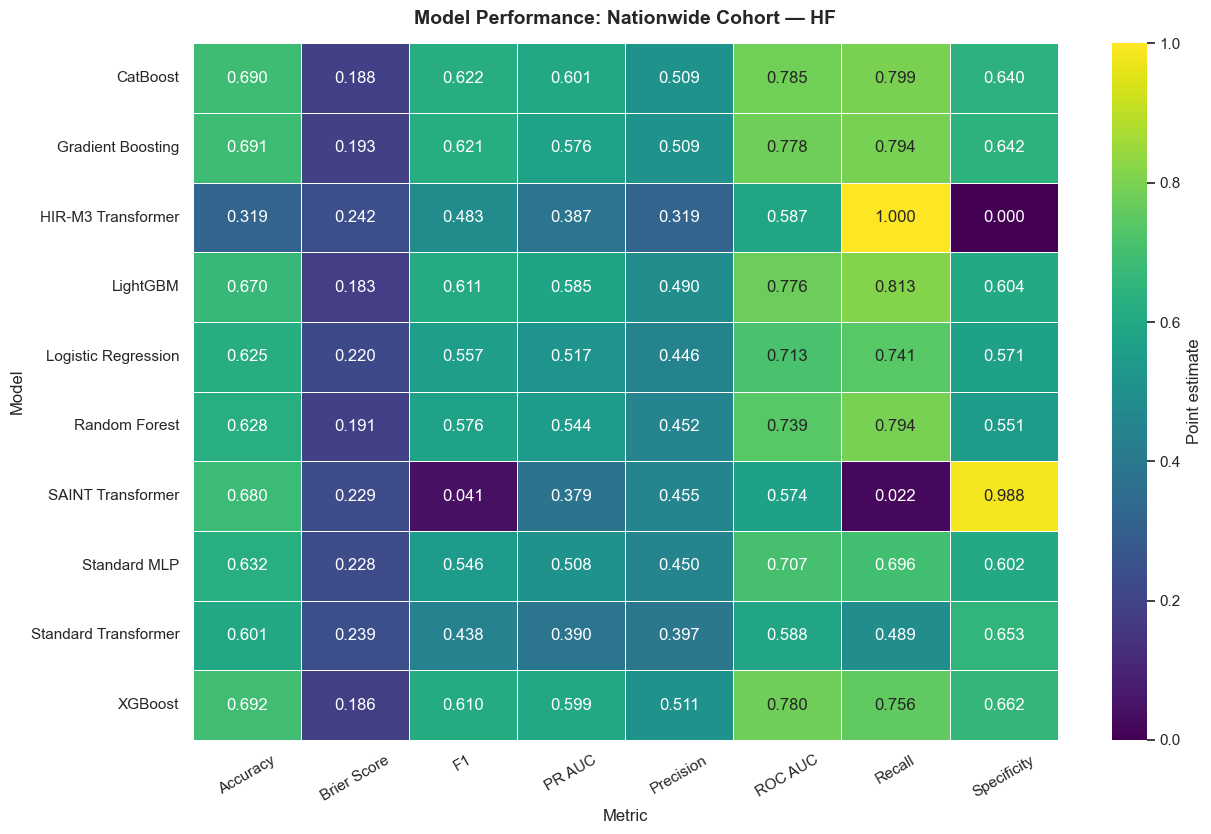

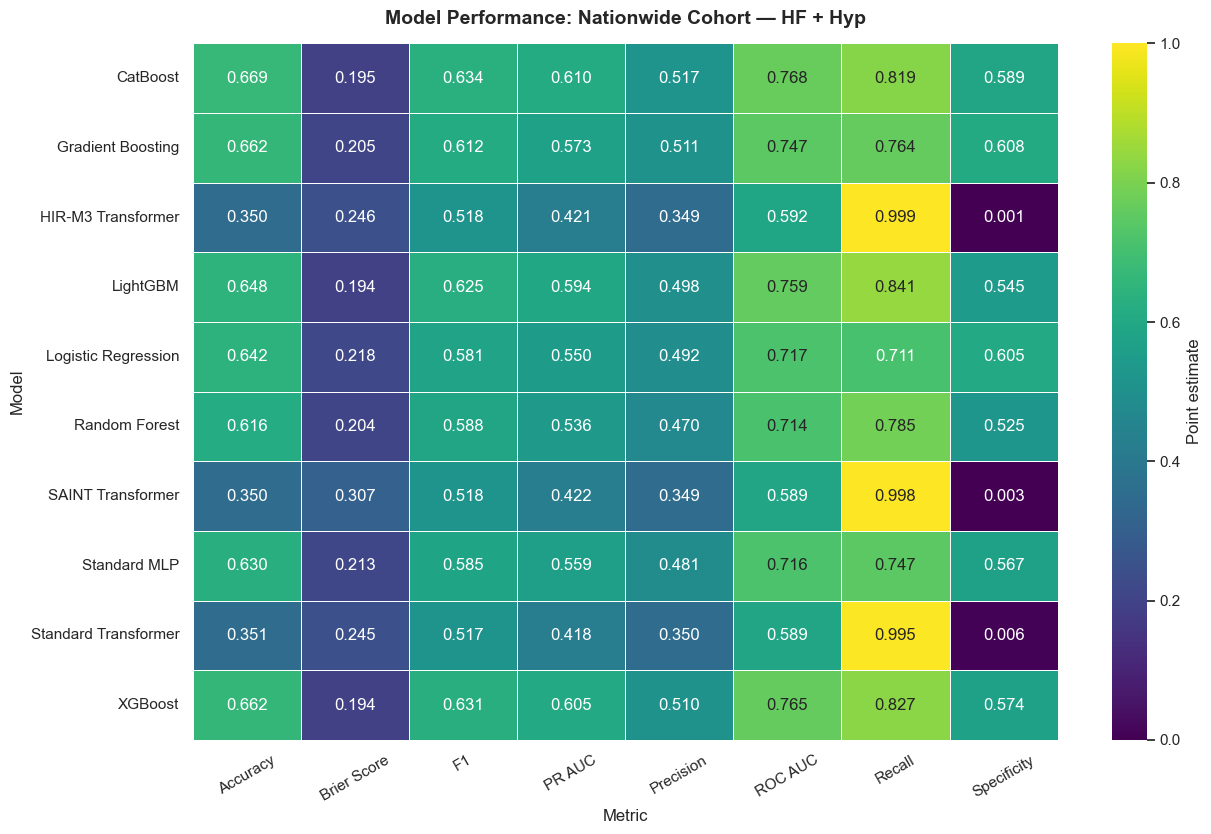

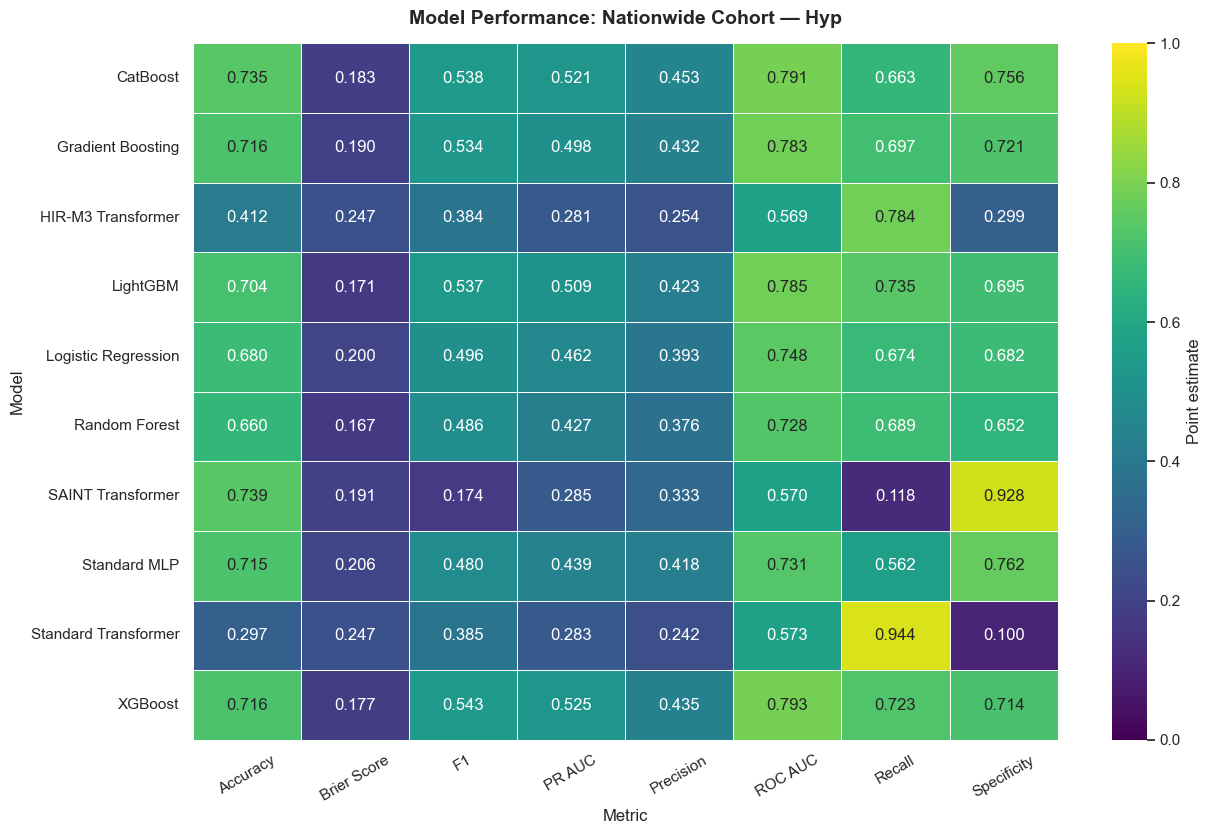

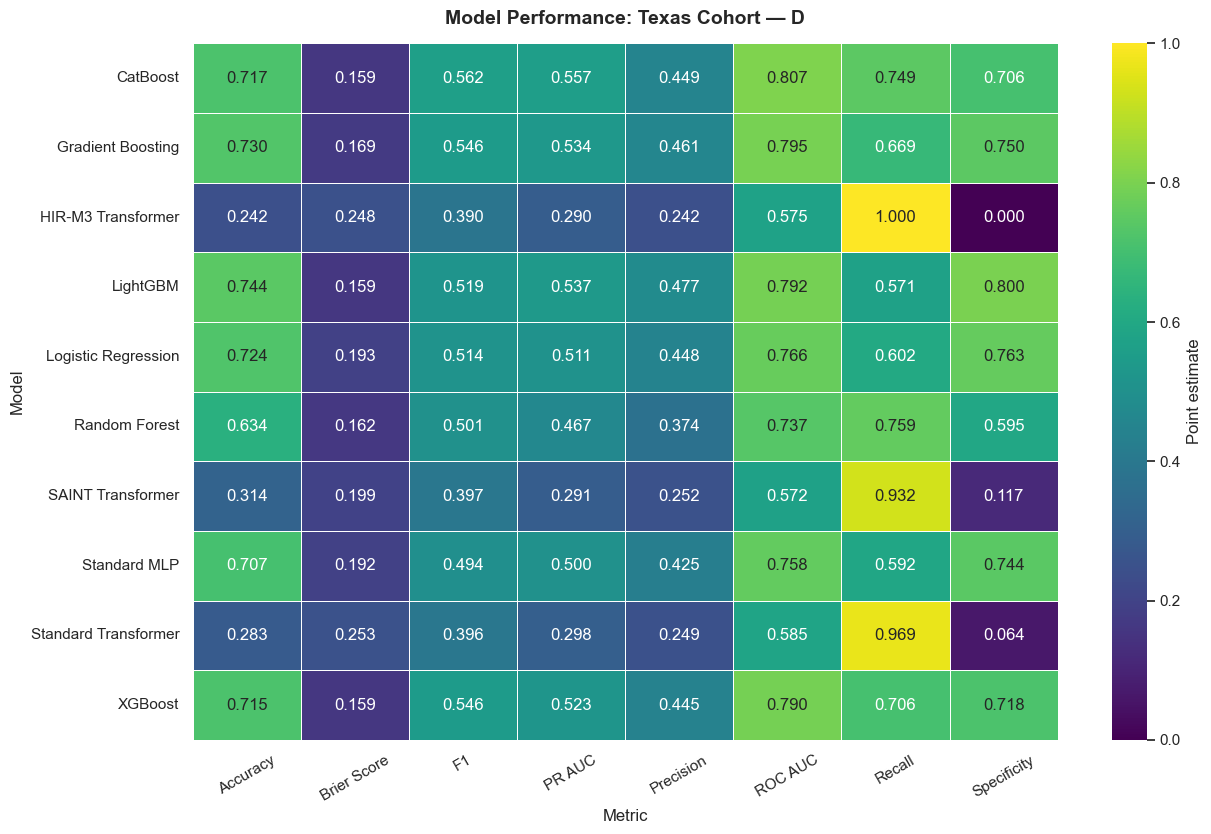

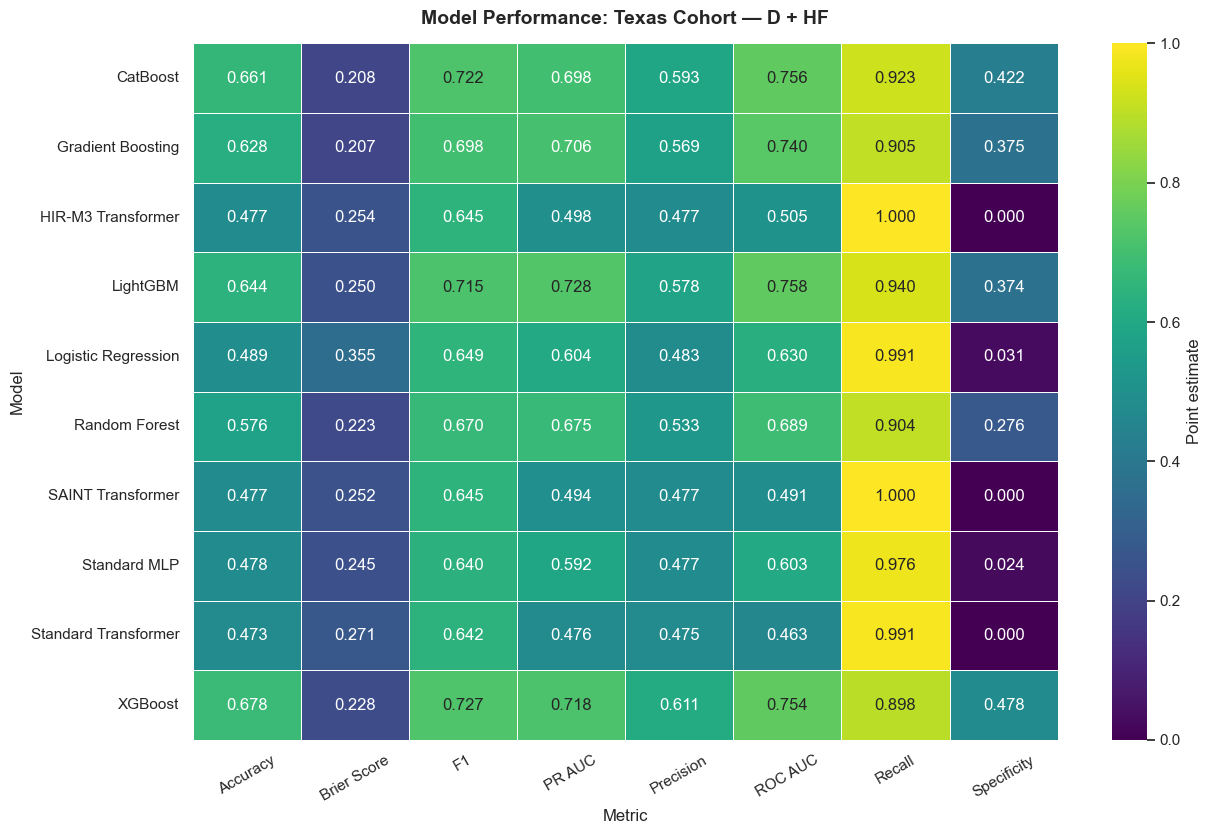

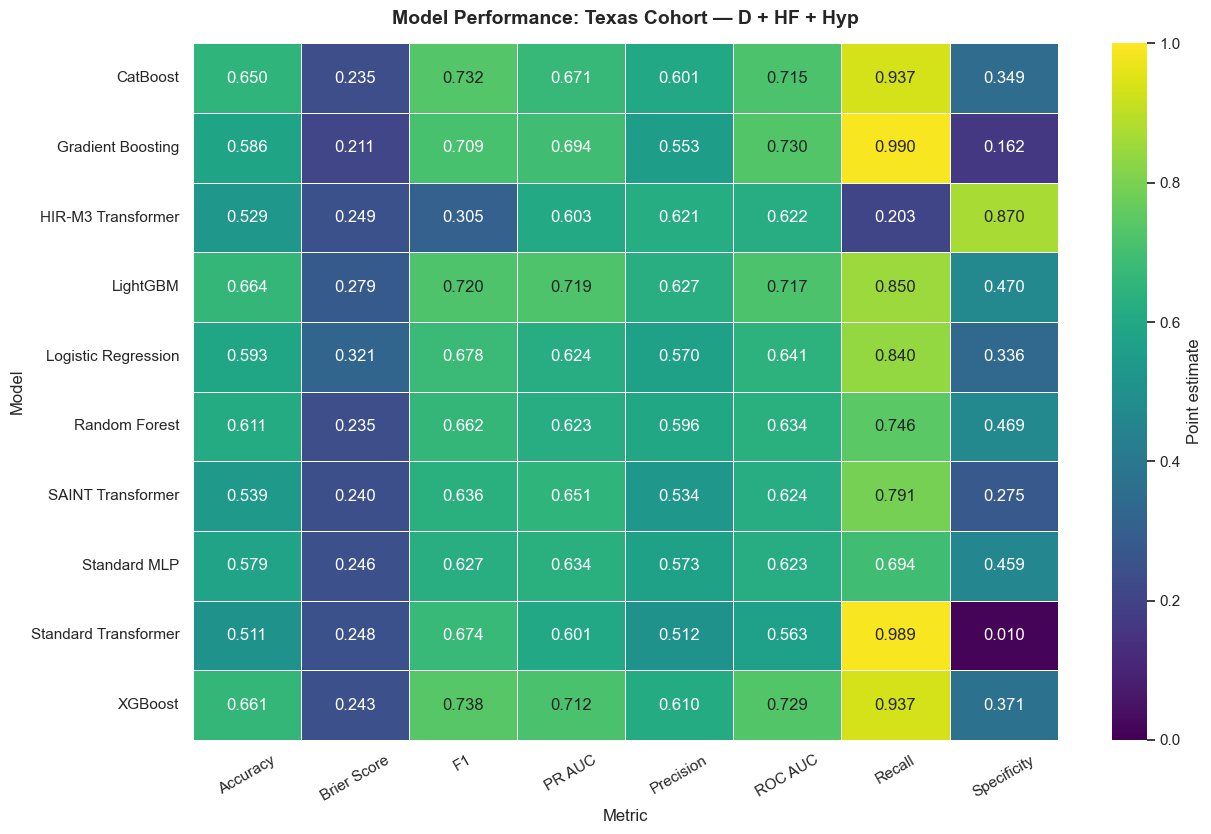

In [ ]:
for (cohort, subgroup), group_df in results_wide_df.groupby(
    ["Cohort", "Subgroup"],
    dropna=False,
    sort=False,
):

    # Handles missing Subgroup values gracefully
    subgroup_label = "All participants" if pd.isna(subgroup) else str(subgroup)

    heatmap_df = (
        group_df
        .drop_duplicates(subset="Model")
        .set_index("Model")[[f"{metric}_value" for metric in metrics]]
        .rename(columns={
            f"{metric}_value": metric_labels[metric]
            for metric in metrics
        })
    )

    if heatmap_df.empty:
        continue

    fig, ax = plt.subplots(
        figsize=(13, max(3.5, 0.7 * len(heatmap_df) + 1.5))
    )

    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": "Point estimate"},
        ax=ax,
    )

    ax.set_title(
        f"Model Performance: {cohort} — {subgroup_label}",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Metric")
    ax.set_ylabel("Model")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

    safe_name = (
        f"{cohort}_{subgroup_label}"
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    fig.tight_layout()
    fig.savefig(
        f"figs/heatmap_{safe_name}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    plt.close(fig)